# Autoencoder (приключение на 1000+ эпох)

не пугайтесь это 1000+ это все вместе
, так по классике пропишем зависимости

In [ ]:
# зависимости
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from torch import nn
import torch.optim as optim
import torchshow as ts
from torch.utils.data import DataLoader, random_split

проверим, если видеоядра cuda

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

напишем трансформ для cifar10 (думал сюда что-то добавить, но, вроде, переобучения не случилось)

In [ ]:
cifar_transform = transforms.Compose([
    transforms.ToTensor()
])

по стандарту качаем cifar10 и делим train выборку на val и train

In [5]:
cifar10_testset = torchvision.datasets.CIFAR10(root='cifar', train=False, download=True, transform=cifar_transform)

cifar10_train_set = torchvision.datasets.CIFAR10(root='cifar', train=True, download=True, transform=cifar_transform)
cifar10_train_set, cifar10_val_set = random_split(cifar10_train_set, [0.8, 0.2])
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

собственно проверка датасета

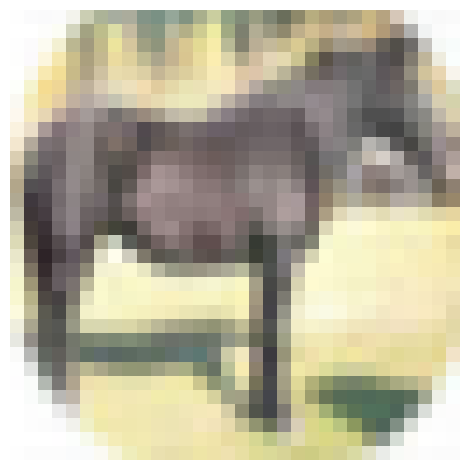

In [6]:
img, cls = cifar10_val_set[2]
ts.show(img)

картинка есть, значит всё ок

посмотрим на размеры картинок

In [7]:
img.shape

torch.Size([3, 32, 32])

3 канала и 32 на 32, учтём это, когда будет составлять vae

выведем больше картинок с классами

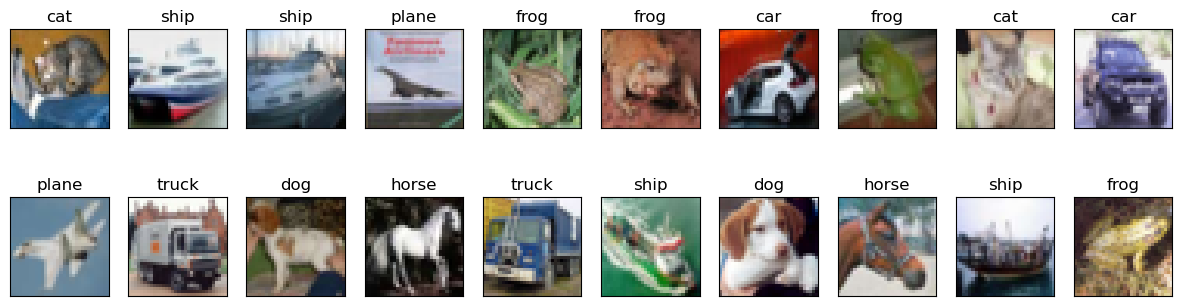

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    img_to_plot = cifar10_testset[i][0].permute(1, 2, 0)
    # img_to_plot = (img_to_plot + 1) / 2
    plt.imshow(img_to_plot)
    plt.xticks([])
    plt.yticks([])
    plt.title(classes[cifar10_testset[i][1]])

plt.show()

Ну и наконец VAE тут будет мой лучший вариант, пробовал без свёрток и resnet архитектуры, но не хватило времени довести их до ума, 
я и так потратил на это много времени((

In [26]:
from torchsummary import summary

class ConvVariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dim, img_shape=(3, 32, 32)):
        super().__init__()
        self.img_shape = img_shape

        self.encoder_conv = nn.Sequential( 
            # вспомним, что наше изображение 3x32x32
            nn.Conv2d(img_shape[0], 64, 3, stride=2, padding=1), # 32x16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),            # 64x8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),           # 256x4x4
            nn.ReLU(),
            nn.Flatten()
        )

        flat_features = 256 * 4 * 4
        self.encoder_common = nn.Sequential(
            nn.Linear(flat_features, 512),
            nn.LeakyReLU(),
        )
        self.encoder_m = nn.Linear(512, latent_dim)
        self.encoder_s = nn.Linear(512, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, flat_features)
        self.decoder_conv = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # 128x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 64x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, img_shape[0], 3, stride=2, padding=1, output_padding=1), # 3x32x32
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = self.encoder_common(x)
        mu = self.encoder_m(x)
        logvar = self.encoder_s(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std, mu, logvar

    def forward(self, x):
        z, mu, logvar = self.encode(x)
        z = self.decoder_input(z)
        y = self.decoder_conv(z)
        return y, mu, logvar

    def process(self, x):
        return self.forward(x)[0]


lat_dim = 128
sae = ConvVariationalAutoEncoder(lat_dim).to(device)
summary(sae, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           1,792
              ReLU-2           [-1, 64, 16, 16]               0
            Conv2d-3            [-1, 128, 8, 8]          73,856
              ReLU-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 256, 4, 4]         295,168
              ReLU-6            [-1, 256, 4, 4]               0
           Flatten-7                 [-1, 4096]               0
            Linear-8                  [-1, 512]       2,097,664
         LeakyReLU-9                  [-1, 512]               0
           Linear-10                  [-1, 128]          65,664
           Linear-11                  [-1, 128]          65,664
           Linear-12                 [-1, 4096]         528,384
        Unflatten-13            [-1, 256, 4, 4]               0
  ConvTranspose2d-14            [-1, 12

такая вот моделька на 3,5 миллиона параметров, скрытый слой - 128, так как 256 не дал особого эффекта, значит этого достаточно

фукция для эпохи

In [ ]:
from tqdm import tqdm

def run_epoch(ae, opt, loss, dataloader, is_train=True, beta = 0.01):
    ae.train(is_train)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for x, _ in tqdm(dataloader):
            x = x.to(device)
            reconstruction, mu, logvar = ae(x)
            recon_loss = loss(reconstruction, x) / x.size(0)
            kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu**2 - torch.exp(logvar), dim=1))

            l = recon_loss + beta * kl_loss

            if (is_train):
                opt.zero_grad()
                l.backward()
                opt.step()
            total_loss += l.item()
    return total_loss / len(dataloader.dataset)

функция для графиков loss

In [11]:
def plot_loss(loss, title, num_epochs):
    plt.title(title)
    plt.plot(loss)
    plt.grid()
    plt.xticks(np.arange(num_epochs))

def plot_losses(train, val, num_epochs):
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 2, 1)
    plot_loss(train, f'Train Loss = {train[-1]}', num_epochs)
    plt.subplot(1, 2, 2)
    plot_loss(val, f'Val Loss = {val[-1]}', num_epochs)
    plt.show()

функция для вывода примеров обучения, я не знаю, всё нормально работало, только когда я на локалку перенес она почему-то криво стала работать

In [12]:
def show_examples(ae, dataset, size):
    ae.eval()
    with torch.no_grad():
        idxs = np.random.randint(0, len(dataset), size)
        x = torch.stack([dataset[i][0] for i in idxs]).to(device)
        y = ae.process(x)
        print("Original images")
        ts.show(x, nrows=1, figsize=(12, 2))
        print("Reconstructed")
        ts.show(y, nrows=1, figsize=(12, 2))

собственно, функция нашего обучения

In [13]:
from IPython.display import clear_output

def run_train_loop(ae, opt, loss, train_loader, val_loader, num_epochs, ex_size):
    train_hist = []
    val_hist = []
    for e in range(num_epochs):
        print("Trainin...")
        train_loss = run_epoch(ae, opt, loss, train_loader)
        train_hist.append(train_loss)
        print("Validating...")
        val_loss = run_epoch(ae, opt, loss, val_loader, is_train=False)
        val_hist.append(val_loss)
        clear_output()
        plot_losses(train_hist, val_hist, num_epochs)
        show_examples(ae, val_loader.dataset, ex_size)

приступим к обучению

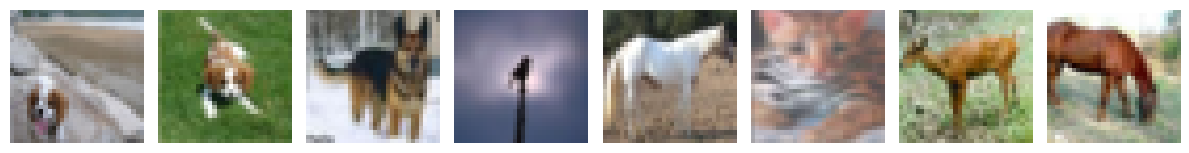

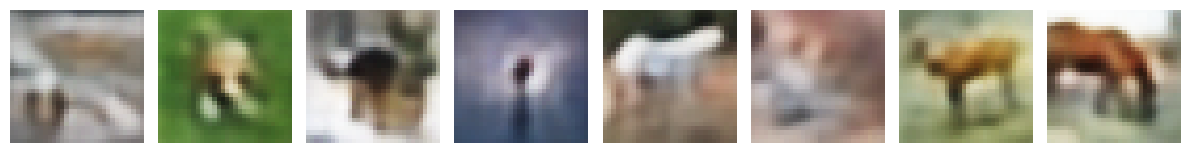

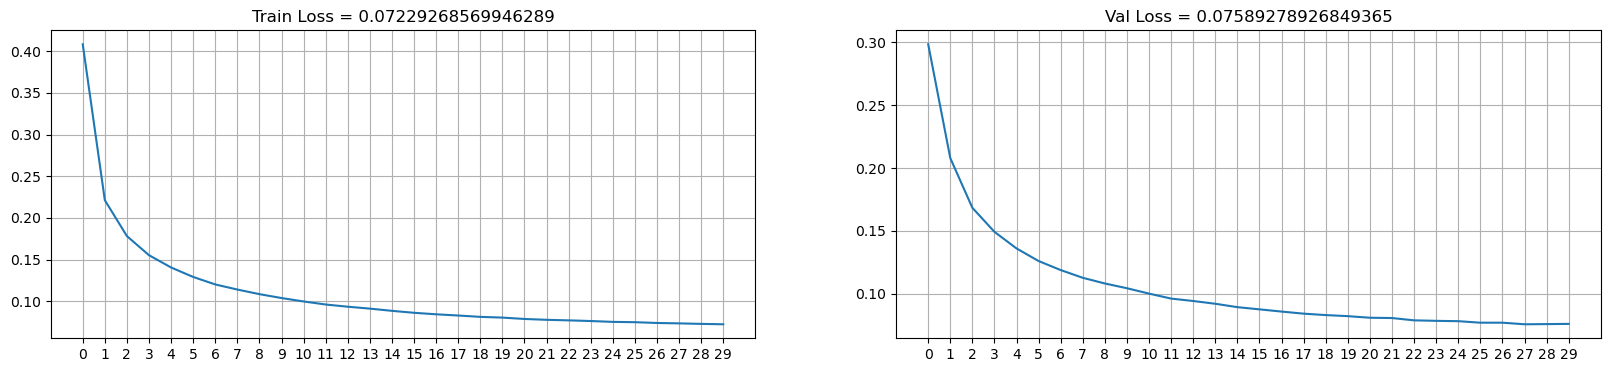

Original images
Reconstructed


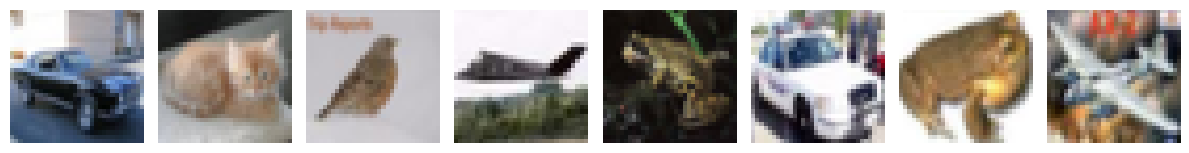

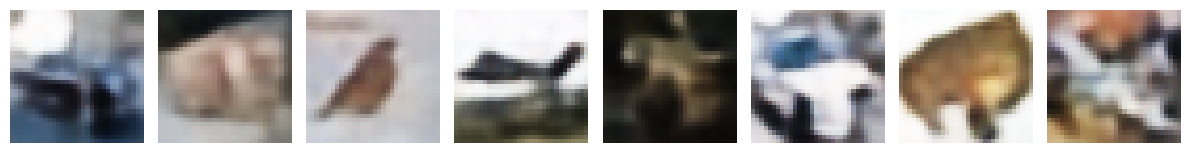

In [50]:
batch_size = 256
num_epochs = 30
lat_dim = 128 # размерность скрытого пространства
ex_size = 8 # число примеров для отрисовки

train_loader = DataLoader(cifar10_train_set, batch_size)
val_loader = DataLoader(cifar10_val_set, batch_size)

sae = ConvVariationalAutoEncoder(lat_dim).to(device)
sae_opt = optim.Adam(sae.parameters(), lr=0.0005)
sae_loss = nn.MSELoss(reduction='sum')
# пробовал другие лоссы, в основном сходилось к тому, что картинки были ещё более размытыми

run_train_loop(sae, sae_opt, sae_loss,
               train_loader, val_loader, num_epochs, ex_size)

мы видим, как модель пытается во всю повторить общие очертания, к сожалению, она не смогла запомнить чёткость, по графикам всё хорошо, обучение прошло стабильно, и модель достигла своего плато

собственно создаём тестовый loader

In [51]:
test_loader = DataLoader(cifar10_testset, batch_size)

In [52]:
img, _ = next(iter(test_loader))
with torch.no_grad():
    z, mu, logvar = sae.encode(img.to(device))
    print("Среднее mu:", mu.mean().item())
    print("Дисперсия mu:", mu.var().item())
    print("Max mu:", mu.max().item(), "Min mu:", mu.min().item())

Среднее mu: -0.0014640791341662407
Дисперсия mu: 0.9418129920959473
Max mu: 6.637433052062988 Min mu: -5.694170951843262


сначала посмотрим на latent измерение

In [53]:
def show_enc_dist(ae, xi, yi, dataset, size):
    idxs = np.random.randint(0, len(dataset), size)
    ae.eval()
    with torch.no_grad():
        # Собираем батч картинок (они уже должны быть 3x32x32 из CIFAR10)
        images = torch.stack([dataset[i][0] for i in idxs]).to(device)

        # Берём только первый элемент кортежа (латентный вектор z)
        z, mu, logvar = ae.encode(images)

    x = z[:, xi].cpu().numpy()
    y = z[:, yi].cpu().numpy()

    plt.figure(figsize=(8, 8))
    # dataset[i][1] — это метка класса для раскраски точек
    plt.scatter(x, y, c=[dataset[i][1] for i in idxs], cmap='tab10', alpha=0.5, s=10)
    plt.colorbar(label='Class ID')
    plt.title(f"Latent Space Dimensions {xi} vs {yi}")
    plt.show()

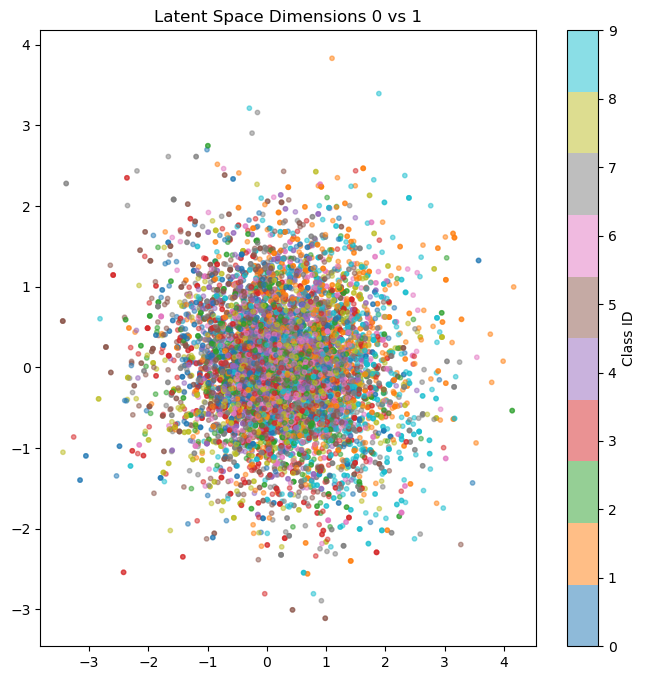

In [17]:
show_enc_dist(sae, 0, 1, cifar10_testset, 10000)

Мы видим, что они образовали единное облако в центре, что огромный плюс, но классы наслоились на друг друга, скорее всего из-за этого и происходит такая нечёткость, но это значит что у нас нет переобучения и оно определяет классы по цветам (мы это увидим ниже), а не по самим классам 

быстрый тест на тестовой выборке

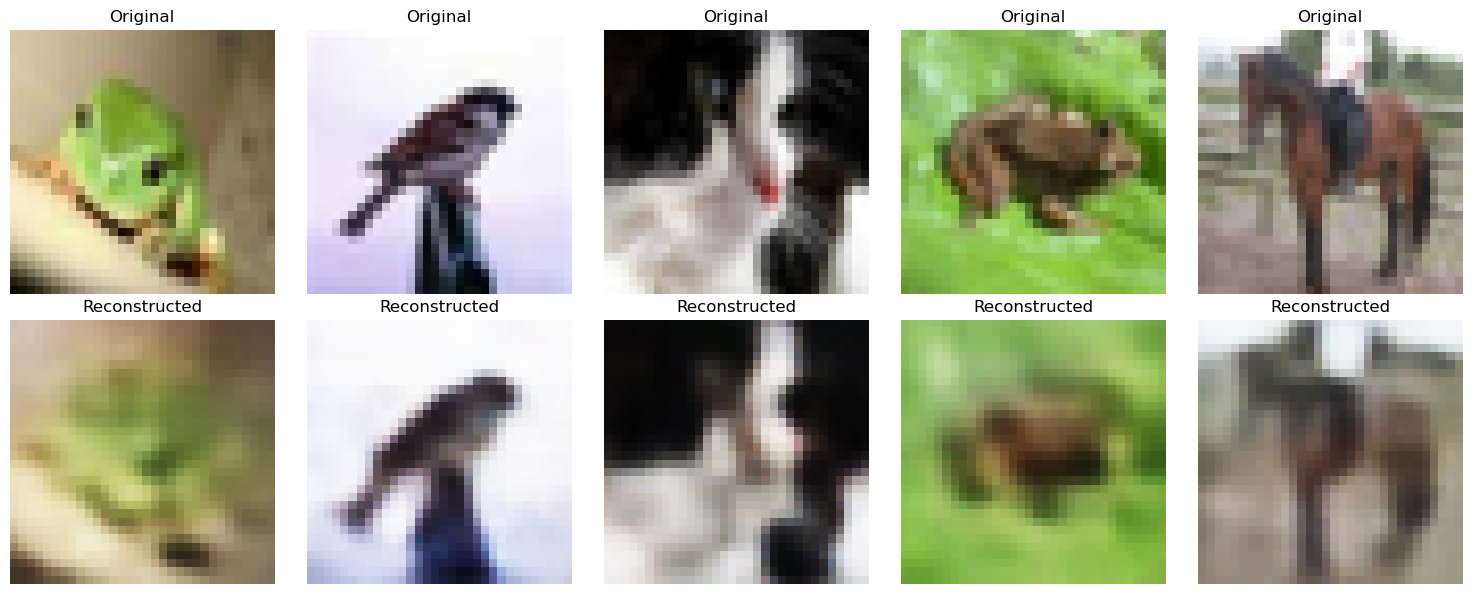

In [54]:
import matplotlib.pyplot as plt
import torch

def quick_test(model, dataset, num_images=5):
    model.eval()
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 3, 6))

    idxs = torch.randint(0, len(dataset), (num_images,))

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            img, _ = dataset[idx]
            img = img.unsqueeze(0).to(device)

            recon_img, _, _ = model(img)

            orig = img.squeeze().cpu().permute(1, 2, 0).numpy()
            recon = recon_img.squeeze().cpu().permute(1, 2, 0).numpy()

            recon = recon.clip(0, 1)

            axes[0, i].imshow(orig)
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')

            axes[1, i].imshow(recon)
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

quick_test(sae, cifar10_testset)

ну то, что мы и видим: слишком размытые классы, но в целом, оно правильно сохранила их форму

In [63]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure

def calculate_metrics(ae, dataloader, device):
    ae.eval()

    fid = FrechetInceptionDistance(feature=64).to("cpu") 
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    
    avg_ssim = 0.0
    with torch.no_grad():
        for x, _ in tqdm(dataloader, desc="Calculating Metrics"):
            x = x.to(device)
            recon, _, _ = ae(x)
            
            avg_ssim += ssim_metric(recon, x).item()
            
            real_img = (x * 255).cpu().type(torch.uint8)
            fake_img = (recon * 255).cpu().type(torch.uint8)
            
            fid.update(real_img, real=True)
            fid.update(fake_img, real=False)
            
    final_fid = fid.compute().item()
    final_ssim = avg_ssim / len(dataloader)
    return final_fid, final_ssim

In [64]:
calculate_metrics(sae, test_loader, device)

Calculating Metrics: 100%|██████████| 40/40 [03:38<00:00,  5.47s/it]


(0.24595503509044647, 0.7420802608132362)

Я так понимаю, что раз FID 0.24, значит это неудачная метрика для нашего датасета, так как она не отражает то, что у нас получилось абсолютное мыло, ещё у неё мало признаков из-за того, что моя видео карта не тянет Inception, из-за чего распознаются на низкоуровневых признаках, которые у фоток совпадают

что подтверждает ssim 0.74, так как оно действительно смогло нарисовать пятно объекта что мы и видели выше  

посмотрим на скрытые слои vae

In [65]:
def find_best_layers(ae, dataloader, device):
    ae.eval()
    all_mu = []
    
    with torch.no_grad():
        for x, _ in dataloader:
            _, mu, _ = ae.encode(x.to(device))
            all_mu.append(mu)
            if len(all_mu) > 20: break

    all_mu = torch.cat(all_mu, dim=0)
    
    variances = torch.var(all_mu, dim=0).cpu().numpy()

    best_indices = np.argsort(variances)[::-1]
    
    print("Топ-5 самых активных слоев (измерений):")
    for i in range(5):
        idx = best_indices[i]
        print(f"Слой z{idx}: дисперсия = {variances[idx]:.4f}")
        
    return best_indices

active_layers = find_best_layers(sae, test_loader, device)

idx1 = active_layers[0]
idx2 = active_layers[1]

Топ-5 самых активных слоев (измерений):
Слой z38: дисперсия = 3.1540
Слой z92: дисперсия = 2.7870
Слой z126: дисперсия = 2.3098
Слой z85: дисперсия = 2.0090
Слой z54: дисперсия = 1.8424


мы видим, что они используются и это значит, что модель их не просто выбросила, а действительно использует

попутешествуем по самым значимым слоям (с высокой дисперсией)

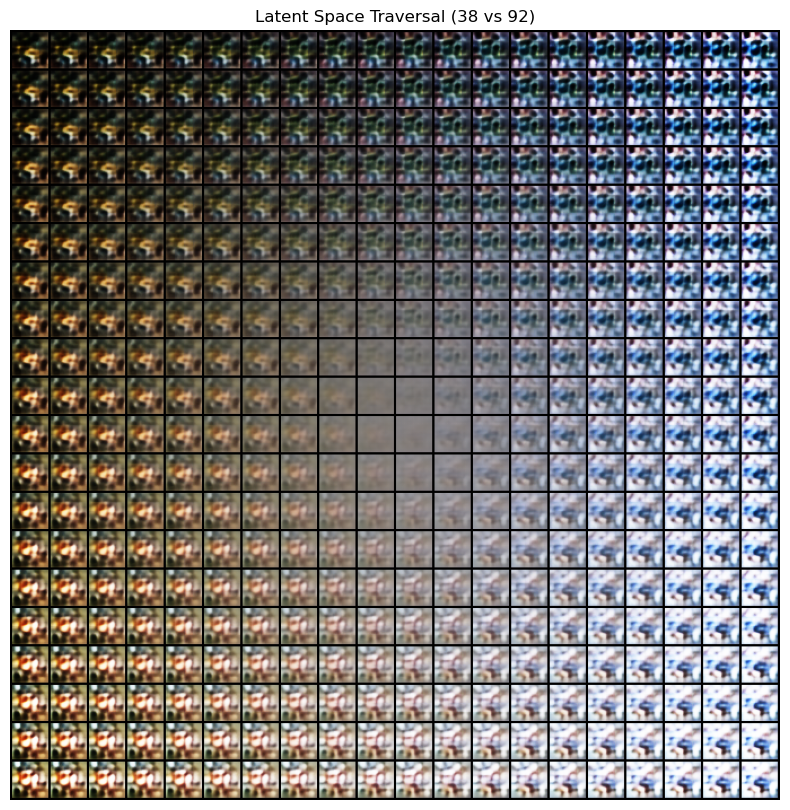

In [ ]:
def to_img(x):
    x = x.clamp(0, 1)
    return x

def show_image(img):
    img = to_img(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
with torch.no_grad():
    n = 20
    latent_x = np.linspace(-10, 10, 20)
    latent_y = np.linspace(-10, 10, 20)
    
    latents = torch.zeros(n * n, lat_dim).to(device)
    
    for i, lx in enumerate(latent_x):
        for j, ly in enumerate(latent_y):
            idx = i * n + j
            latents[idx, idx1] = lx
            latents[idx, idx2] = ly

    z = sae.decoder_input(latents)
    image_recon = sae.decoder_conv(z).cpu()

    # Отрисовка
    plt.figure(figsize=(10, 10))
    grid_img = torchvision.utils.make_grid(image_recon, nrow=n, padding=2)
    plt.imshow(grid_img.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f"Latent Space Traversal ({idx1} vs {idx2})")
    plt.show()

Так мы видим, что скрытое пространство хорошее, так как у нас получился градиент:

* Ось X: Вероятно, отвечает за цветовую температуру и баланс каналов (переход от теплых коричневых тонов к холодным синим).
* Ось Y: Влияет на контрастность и детализацию объектов.

#### **Игого:**

##### 1. Архитектурный анализ
В ходе работы была спроектирована и обучена **сверточная вариационная автокодирующая сеть (Conv-VAE)** на датасете CIFAR-10, которая показала нормальные результаты

##### 2. Интерпретация метрик
* **SSIM ≈ 0.74:** Высокий показатель структурного сходства подтверждает, что модель успешно восстанавливает геометрию объектов, их положение и доминирующие цветовые пятна.
* **FID ≈ 0.24:** Так как это аномально низкое значение FID. В данном случае метрика указывает на высокую статистическую близость низкоуровневых признаков и подтверждает хороший ssim

##### 3. Качество латентного пространства
* **Визуализация (Latent Traversal):** Сетка сгенерированных изображений демонстрирует **непрерывность и гладкость** скрытого пространства. Плавные цветовые и морфологические переходы подтверждают, что модель научилась интерполировать признаки, а не просто копировать обучающую выборку.
* **Распределение классов:** Сильное перекрытие кластеров на графике рассеяния является следствием работы KL-регуляризации. Модель успешно сгруппировала данные по визуальному сходству, сохранив высокую плотность распределения.